In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

np.random.seed(42)

In [2]:
def parse_file(path, users_set, movies_set):
    with open(path, 'r') as f:
        for line in f:
            if re.match(r"^\d+:", line):
                movie_id = int(re.match(r"^(\d+):", line).group(1))
                movies_set.add(movie_id)
            else:
                customer_id, rating, date = line.split(",")
                users_set.add(int(customer_id))
    return users_set, movies_set

In [3]:
users_set = set()
movies_set = set()

# paths = ["data/combined_data_1.txt", "data/combined_data_2.txt", "data/combined_data_3.txt", "data/combined_data_4.txt"]
paths = ["data/combined_data_1.txt"]

for path in paths:
    parse_file(path, users_set, movies_set)
    
user_list = sorted(list(users_set))
movie_list = sorted(list(movies_set))

user_index = {user_id: i for i, user_id in enumerate(user_list)}
movie_index = {movie_id: j for j, movie_id in enumerate(movie_list)}

# initialize matrix
matrix = np.zeros((len(user_list), len(movie_list)))

In [4]:
def fill_matrix(path, matrix, user_index, movie_index):
    with open(path, 'r') as f:
        movie_id = None
        for line in f:
            line = line.strip()
            if re.match(r"^\d+:", line):
                movie_id = int(re.match(r"^(\d+):", line).group(1))
            else:
                customer_id, rating, date = line.split(",")
                i = user_index[int(customer_id)]
                j = movie_index[movie_id]
                matrix[i, j] = float(rating)
    return matrix

In [5]:
# filling in the matrix
for path in paths:
    fill_matrix(path, matrix, user_index, movie_index)

In [6]:
matrix.shape

(470758, 4499)

In [7]:
np.sum(matrix == 0)

2093886478

## Netflix problem solution

In [8]:
def soft_thresholding(X, lambda_):
    U, D, Vh = np.linalg.svd(X, full_matrices=False)
    D_lambda = np.maximum(D - lambda_, 0)
    D_lambda = np.diag(D_lambda)
    return U @ D_lambda @ Vh

# self imputation for matrix completion
def matrix_completion(X, mult=1, k=5, max_iter=100, eps=1e-6, return_only_last=True):
    X_old = np.zeros_like(X)
    mask = X == 0
    
    # compute s_max
    U, s, Vh = np.linalg.svd(X, full_matrices=False)
    s_max = s[0] * mult

    # decreasing grid of lambda reg
    lambda_max = 0.5 * s_max
    lambda_min = 0.01 * s_max
    
    lambdas = np.logspace(
        np.log10(lambda_min),
        np.log10(lambda_max),
        k
    )[::-1]
    
    solutions = []
    
    for lambda_ in lambdas:
        for _ in range(max_iter):
            X_combined = np.zeros_like(X)
            # filling observed entries from X
            X_combined[~mask] = X[~mask]
            # filling missing entries from X_old
            X_combined[mask] = X_old[mask]
            
            X_new = soft_thresholding(X_combined, lambda_)
            
            # forcing true values
            X_new[~mask] = X[~mask]
            
            # early stopping
            if np.linalg.norm(X_new - X_old) / (np.linalg.norm(X_old) + 1e-8) < eps:
                X_old = X_new
                break
            X_old = X_new
            
        if not return_only_last:
            solutions.append(X_new)
    if return_only_last:
        return X_new
    return solutions

## Synthetic examples

In [9]:
def generate_synthetic_matrix_with_mask(
    n_users=100,
    n_movies=100,
    min_rating=1,
    max_rating=5,
    sparsity=0.9,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)

    X_complete = np.random.randint(min_rating, max_rating + 1, size=(n_users, n_movies))

    mask = np.random.rand(n_users, n_movies) > sparsity
    X_observed = X_complete.copy()
    X_observed[~mask] = 0.0

    return X_complete, X_observed, mask


In [10]:
A_complete, A, mask = generate_synthetic_matrix_with_mask(n_users=100, n_movies=100, sparsity=0.5, seed=42)

In [12]:
A_completed = matrix_completion(A)
rmse = np.sqrt(np.mean((A_completed - A_complete)**2))
print("RMSE on missing entries:", rmse)

RMSE on missing entries: 1.9116389446814501


In [19]:
sparsity_list = np.arange(0.1, 1.0, 0.1)
repeats = 5
rmse_list = []

for sparsity in sparsity_list:
    mean_error = 0
    for _ in range(repeats):
        A_complete, A, mask = generate_synthetic_matrix_with_mask(n_users=100, n_movies=100, sparsity=sparsity, seed=42)
        A_completed = matrix_completion(A)
        rmse = np.sqrt(np.mean((A_completed - A_complete)**2))
        mean_error += rmse
    rmse_list.append(mean_error / repeats)

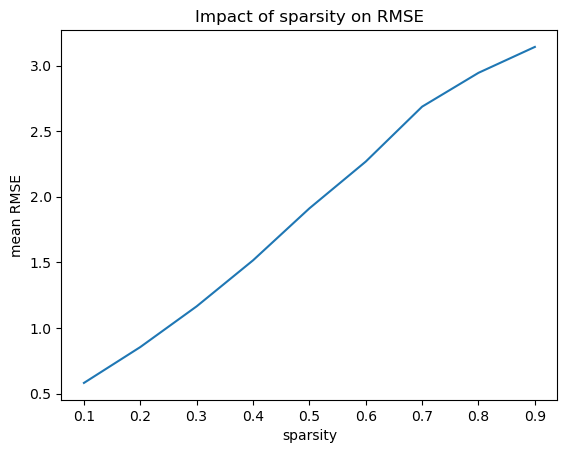

In [20]:
plt.plot(sparsity_list, rmse_list)
plt.xlabel("sparsity")
plt.ylabel("mean RMSE")
plt.title("Impact of sparsity on RMSE")
plt.show()

## Netflix data

In [116]:
matrix.shape

(470758, 4499)

In [117]:
# active matrix - ignoring rows with too little values

min_user_ratings = 10
min_movie_ratings = 10

user_activity = (matrix != 0).sum(axis=1)
movie_activity = (matrix != 0).sum(axis=0)

active_users = np.where(user_activity >= min_user_ratings)[0]
active_movies = np.where(movie_activity >= min_movie_ratings)[0]

matrix_active = matrix[np.ix_(active_users, active_movies)]

In [118]:
# downsampling

n_users_sample = 100
user_idx = np.random.choice(matrix_active.shape[0], size=n_users_sample, replace=False)

n_movies_sample = 100
movie_idx = np.random.choice(matrix_active.shape[1], size=n_movies_sample, replace=False)

matrix_sub = matrix_active[np.ix_(user_idx, movie_idx)]

In [119]:
matrix_sub.shape

(100, 100)

In [120]:
print(matrix_sub)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 3. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 4. 0.]]


In [121]:
np.sum(matrix_sub == 0) / (n_users_sample * n_movies_sample) # almost all entries are 0

0.9753

In [122]:
mask = matrix_sub > 0
mean_rating = matrix_sub[mask].mean()

X_centered = matrix_sub.copy()
X_centered[mask] -= mean_rating
mean_rating

3.4412955465587043

In [123]:
X_completed_centered = matrix_completion(X_centered, mult=0.01, k=20)
X_completed = X_completed_centered + mean_rating
X_completed = np.clip(X_completed, 1, 5)
X_completed

array([[3.44129555, 3.44129555, 3.44129555, ..., 3.44129555, 3.44129555,
        3.44129555],
       [3.44129555, 3.44129555, 3.44129555, ..., 3.44129555, 3.44129555,
        3.44129555],
       [3.44129555, 3.44129555, 3.44624043, ..., 3.44129555, 3.24495395,
        3.44129555],
       ...,
       [3.44129555, 3.44129555, 3.        , ..., 3.44129555, 2.94286047,
        3.44129555],
       [3.44129555, 3.44129555, 3.53307804, ..., 3.44129555, 3.721458  ,
        3.44129555],
       [3.44129555, 3.44129555, 3.30718587, ..., 3.44129555, 4.        ,
        3.44129555]])

In [124]:
X_completed.min(), X_completed.max(), X_completed.mean(), X_completed.std()

(1.0, 5.0, 3.4424874273603185, 0.2015472976370177)

In [125]:
# stats on imputed ratings

mask = matrix_sub == 0
imputed = X_completed[mask]

{
    "count": imputed.size,
    "min": imputed.min(),
    "max": imputed.max(),
    "mean": imputed.mean(),
    "std": imputed.std(),
    "p25": np.percentile(imputed, 25),
    "median": np.median(imputed),
    "p75": np.percentile(imputed, 75),
}

{'count': 9753,
 'min': 2.163373776724919,
 'max': 4.568312043312233,
 'mean': 3.442517612386259,
 'std': 0.09352786189583559,
 'p25': 3.4412955465587043,
 'median': 3.4412955465587043,
 'p75': 3.4412955465587043}

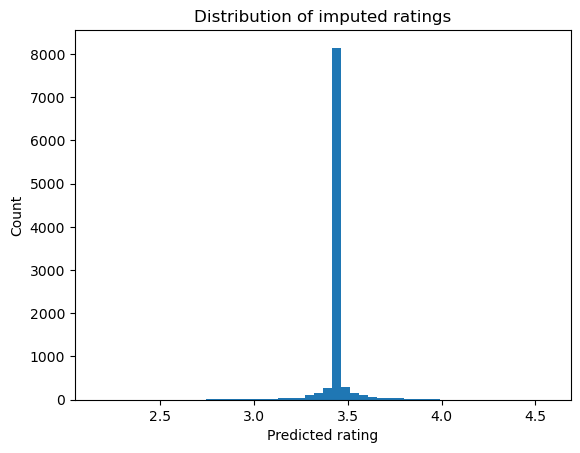

In [126]:
plt.hist(imputed, bins=50)
plt.xlabel("Predicted rating")
plt.ylabel("Count")
plt.title("Distribution of imputed ratings")
plt.show()

# very narrow distribution, predictions around mean rating